<IMG SRC="https://ucalgary.ca/themes/ucalgary/ucws_theme/images/UCalgary.svg" WIDTH=250 ALIGN="right">    </IMG>
## Gas Exchange Threshold (GET) & Respiratory Compensation Point (RCP)

#### Developed by Brooklyn Anderson at the University of Calgary

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/demo-knes381/subject_1321.xlsx
/kaggle/input/demo-knes381/subject_1432.xlsx
/kaggle/input/demo-knes381/subject_1321.csv
/kaggle/input/demo-knes381/subject_1232.csv
/kaggle/input/demo-knes381/VO2_CSV.csv
/kaggle/input/demo-knes381/subject_1232.xlsx
/kaggle/input/demo-knes381/subject_1432.csv
/kaggle/input/demo-knes381/subject_1523.csv
/kaggle/input/demo-knes381/VO2_excel.xlsx
/kaggle/input/demo-knes381/subject_1523.xlsx


In [2]:
# Load new data
df = pd.read_csv('/kaggle/input/demo-knes381/subject_1523.csv')

# Clean column names
df.columns = df.columns.str.replace('"', '', regex=False)
df.columns = df.columns.str.strip()

# Remove non-data 
df = df.iloc[3:]

# Convert to number
df = df.apply(pd.to_numeric, errors='coerce')

# Reset
df = df.reset_index(drop=True)

# Check data
print(df.columns.tolist())
print(df.head())
print(df.info())

['TIME', 'VO2', 'VO2/kg', 'METS', 'VCO2', 'VE', 'RER', 'RR', 'Vt', 'FEO2', 'FECO2', 'HR', 'VE/', 'VE/   .1', 'PetCO2', 'PO']
       TIME       VO2     VO2/kg      METS      VCO2         VE       RER  \
0  0.514000  1.459290  16.582838  4.737954  1.112682  41.919689  0.762482   
1  1.022167  1.504223  17.093439  4.883840  1.160519  42.434860  0.771507   
2  1.519834  1.555103  17.671625  5.049036  1.147277  41.991577  0.737750   
3  2.012334  1.745615  19.836536  5.667582  1.338574  46.513016  0.766821   
4  2.532000  1.667379  18.947485  5.413567  1.274816  43.739609  0.764563   

          RR        Vt       FEO2     FECO2    HR        VE/   VE/   .1  \
0  21.400778  1.958793  16.275774  3.774875  87.0  28.726089  37.674450   
1  21.646441  1.960362  16.181290  3.888129  89.0  28.210491  36.565426   
2  22.103148  1.899801  16.005651  3.884471  84.0  27.002441  36.601089   
3  16.243654  2.863458  15.907585  4.089391  92.0  26.645630  34.748173   
4  23.091724  1.894168  15.831031  4.

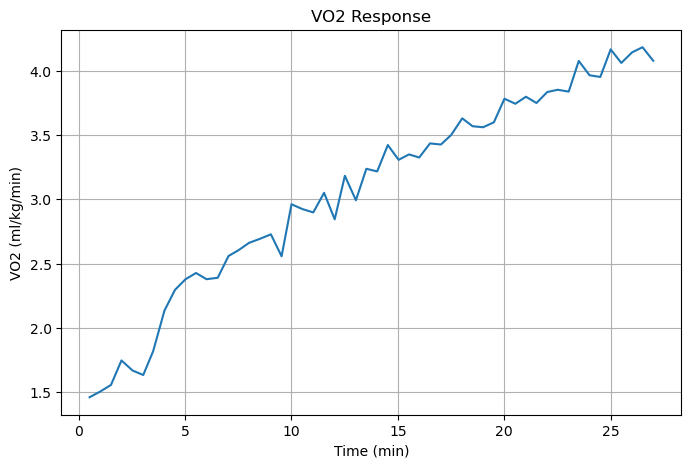

In [3]:
# Variables for plotting
time = df["TIME"]
vo2 = df["VO2"]
vco2 = df["VCO2"]
feco2 = df["FECO2"]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(time, vo2)
plt.xlabel("Time (min)")
plt.ylabel("VO2 (ml/kg/min)")
plt.title("VO2 Response")
plt.grid(True)
plt.show()

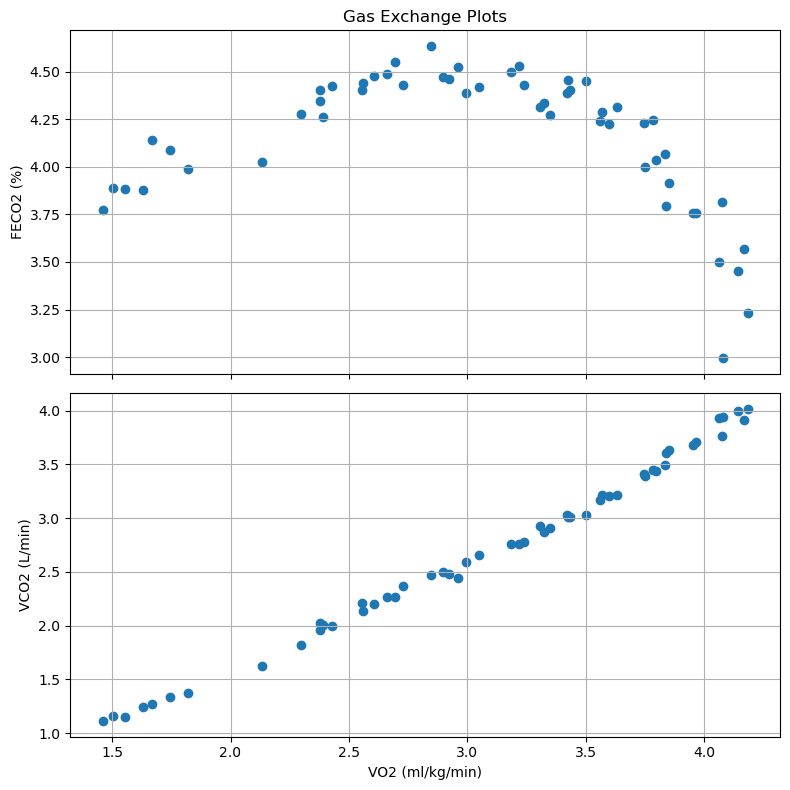

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

axes[0].scatter(vo2, feco2)
axes[0].set_ylabel("FECO2 (%)")
axes[0].set_title("Gas Exchange Plots")
axes[0].grid(True)

axes[1].scatter(vo2, vco2)
axes[1].set_xlabel("VO2 (ml/kg/min)")
axes[1].set_ylabel("VCO2 (L/min)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
# Smooth FECO2
feco2_smooth = feco2.rolling(window=5, center=True).mean()

# GET = peak FECO2
get_idx = feco2_smooth.idxmax()
get_vo2 = vo2.iloc[get_idx]

# Look after GET
after_get = feco2_smooth.iloc[get_idx+1:-5]

# Find where FECO2 reaches its LOWEST point after GET
rcp_idx = after_get.idxmin()
rcp_vo2 = vo2.iloc[rcp_idx]

print("GET VO2:", get_vo2)
print("RCP VO2:", rcp_vo2)

GET VO2: 2.898469
RCP VO2: 3.953282


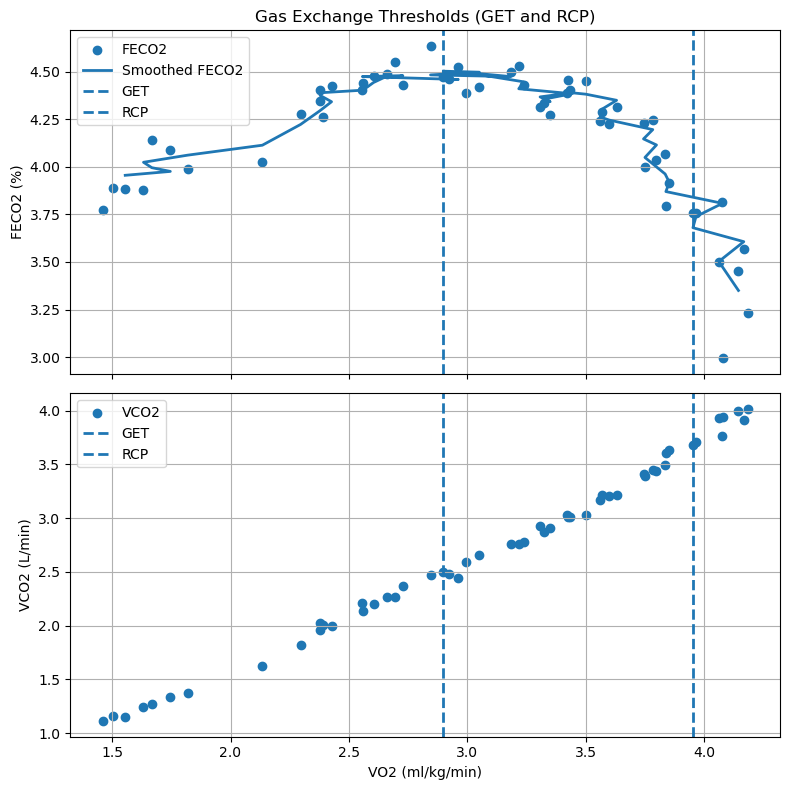

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)

# FECO2 plot
axes[0].scatter(vo2, feco2, label="FECO2")
axes[0].plot(vo2, feco2_smooth, linewidth=2, label="Smoothed FECO2")
axes[0].axvline(get_vo2, linestyle='--', linewidth=2, label='GET')
axes[0].axvline(rcp_vo2, linestyle='--', linewidth=2, label='RCP')
axes[0].set_ylabel("FECO2 (%)")
axes[0].set_title("Gas Exchange Thresholds (GET and RCP)")
axes[0].grid(True)
axes[0].legend()

# VCO2 plot
axes[1].scatter(vo2, vco2, label="VCO2")
axes[1].axvline(get_vo2, linestyle='--', linewidth=2, label='GET')
axes[1].axvline(rcp_vo2, linestyle='--', linewidth=2, label='RCP')
axes[1].set_xlabel("VO2 (ml/kg/min)")
axes[1].set_ylabel("VCO2 (L/min)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()